# RQ2_refined


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


  Model  Accuracy  Precision    Recall        F1       ROC
0    LR  0.608696   0.568841  0.608696  0.583765  0.729225
1    RF  0.739130   0.700483  0.739130  0.690217  0.766807
2   XGB  0.608696   0.588406  0.608696  0.597656  0.714908
3   SVM  0.608696   0.370510  0.608696  0.460635  0.450171


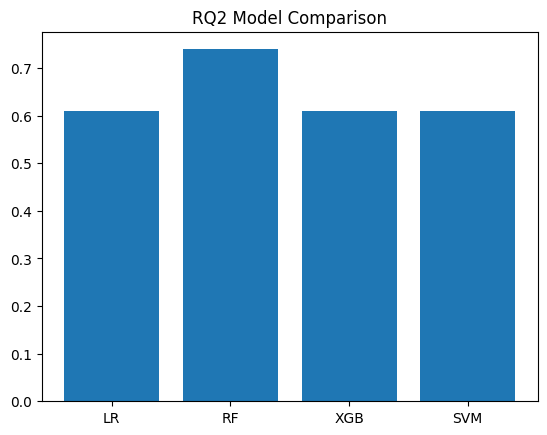

In [11]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

df = pd.read_csv('/kaggle/input/datasets/sehaj1104/indian-road-accident-dataset-20222025/indian_roads_dataset.csv')

df = df.dropna()

X = df.drop('accident_severity', axis=1)
y = df['accident_severity']
y = y.map({
    'minor': 0,
    'major': 1,
    'fatal': 2
})

X = pd.get_dummies(X)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

models = {
    "LR": LogisticRegression(max_iter=1000),
    "RF": RandomForestClassifier(),
    "XGB": XGBClassifier(eval_metric='logloss'),
    "SVM": SVC(probability=True)
}

rows = []

for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)

    if hasattr(m, "predict_proba"):
        prob = m.predict_proba(X_test)
        roc = roc_auc_score(y_test, prob, multi_class='ovr')
    else:
        roc = 0

    rows.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred, average='weighted'),
        recall_score(y_test, pred, average='weighted'),
        f1_score(y_test, pred, average='weighted'),
        roc
    ])

res_df = pd.DataFrame(rows, columns=["Model","Accuracy","Precision","Recall","F1","ROC"])

res_df
res_df.to_csv("RQ2_table.csv", index=False)

plt.figure()
plt.bar(res_df["Model"], res_df["Accuracy"])
plt.title("RQ2 Model Comparison")
plt.savefig("RQ2_figure.pdf")
print(res_df)
